In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

In [2]:
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

X_and, y_and

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([0, 0, 0, 1]))

In [3]:
and_nn = MLPClassifier(hidden_layer_sizes=(), activation='logistic', 
                      solver='lbfgs', max_iter=1000, random_state=42)
and_nn.fit(X_and, y_and)

and_nn.predict(X_and)

array([0, 0, 0, 1])

In [4]:
and_nn.coefs_[0], and_nn.intercepts_[0]

(array([[12.22961805],
        [12.44097415]]),
 array([-18.84234139]))

In [5]:
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

X_or, y_or

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([0, 1, 1, 1]))

In [6]:
or_nn = MLPClassifier(hidden_layer_sizes=(), activation='logistic', 
                     solver='lbfgs', max_iter=1000, random_state=42)
or_nn.fit(X_or, y_or)

or_nn.predict(X_or)

array([0, 1, 1, 1])

In [7]:
or_nn.coefs_[0], or_nn.intercepts_[0]

(array([[12.59966559],
        [12.60028484]]),
 array([-5.89439838]))

In [8]:
X_not = np.array([[0], [1]])
y_not = np.array([1, 0])

X_not, y_not

(array([[0],
        [1]]),
 array([1, 0]))

In [9]:
not_nn = MLPClassifier(hidden_layer_sizes=(), activation='logistic', 
                      solver='lbfgs', max_iter=1000, random_state=42)
not_nn.fit(X_not, y_not)

not_nn.predict(X_not)

array([1, 0])

In [10]:
not_nn.coefs_[0], not_nn.intercepts_[0]

(array([[-13.18415452]]), array([6.61118495]))

In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def manual_and_gate(x1, x2):
    w1, w2 = 15, 15  
    bias = -20       
    output = sigmoid(w1*x1 + w2*x2 + bias)
    return 1 if output > 0.5 else 0

test_inputs = [[0,0], [0,1], [1,0], [1,1]]
[manual_and_gate(x[0], x[1]) for x in test_inputs]

[0, 0, 0, 1]

In [12]:
def manual_or_gate(x1, x2):
    w1, w2 = 15, 15  
    bias = -10       
    output = sigmoid(w1*x1 + w2*x2 + bias)
    return 1 if output > 0.5 else 0

[manual_or_gate(x[0], x[1]) for x in test_inputs]

[0, 1, 1, 1]

In [13]:
def manual_not_gate(x):
    w = -15          
    bias = 10        
    output = sigmoid(w*x + bias)
    return 1 if output > 0.5 else 0

test_not_inputs = [0, 1]
[manual_not_gate(x) for x in test_not_inputs]

[1, 0]

## Neural Network Structure Analysis

**AND Gate:**
- Input layer: 2 neurons (X1, X2)
- No hidden layer (single perceptron)
- Output layer: 1 neuron
- Activation: Sigmoid
- Weights: Both inputs need high positive weights (~15)
- Bias: Large negative bias (~-20) ensures output is 1 only when both inputs are 1

**OR Gate:**
- Input layer: 2 neurons (X1, X2)  
- No hidden layer (single perceptron)
- Output layer: 1 neuron
- Activation: Sigmoid
- Weights: Both inputs need moderate positive weights (~15)
- Bias: Moderate negative bias (~-10) allows output to be 1 when at least one input is 1

**NOT Gate:**
- Input layer: 1 neuron (X)
- No hidden layer (single perceptron)
- Output layer: 1 neuron
- Activation: Sigmoid
- Weight: Large negative weight (~-15) inverts the input
- Bias: Positive bias (~10) shifts the decision boundary

In [14]:
class SimplePerceptron:
    def __init__(self, input_size):
        self.weights = np.random.randn(input_size) * 0.1
        self.bias = np.random.randn() * 0.1
        
    def predict(self, x):
        return sigmoid(np.dot(x, self.weights) + self.bias)
    
    def train(self, X, y, epochs=1000, lr=1.0):
        for epoch in range(epochs):
            for i in range(len(X)):
                prediction = self.predict(X[i])
                error = y[i] - prediction
                
                self.weights += lr * error * prediction * (1 - prediction) * X[i]
                self.bias += lr * error * prediction * (1 - prediction)

and_perceptron = SimplePerceptron(2)
and_perceptron.train(X_and, y_and)

[1 if and_perceptron.predict(x) > 0.5 else 0 for x in X_and]

[0, 0, 0, 1]

In [15]:
and_perceptron.weights, and_perceptron.bias

(array([5.50782213, 5.50422898]), np.float64(-8.344994059873615))

In [16]:
or_perceptron = SimplePerceptron(2)
or_perceptron.train(X_or, y_or)

[1 if or_perceptron.predict(x) > 0.5 else 0 for x in X_or]

[0, 1, 1, 1]

In [17]:
not_perceptron = SimplePerceptron(1)
not_perceptron.train(X_not, y_not)

[1 if not_perceptron.predict(np.array([x])) > 0.5 else 0 for x in [0, 1]]

[1, 0]

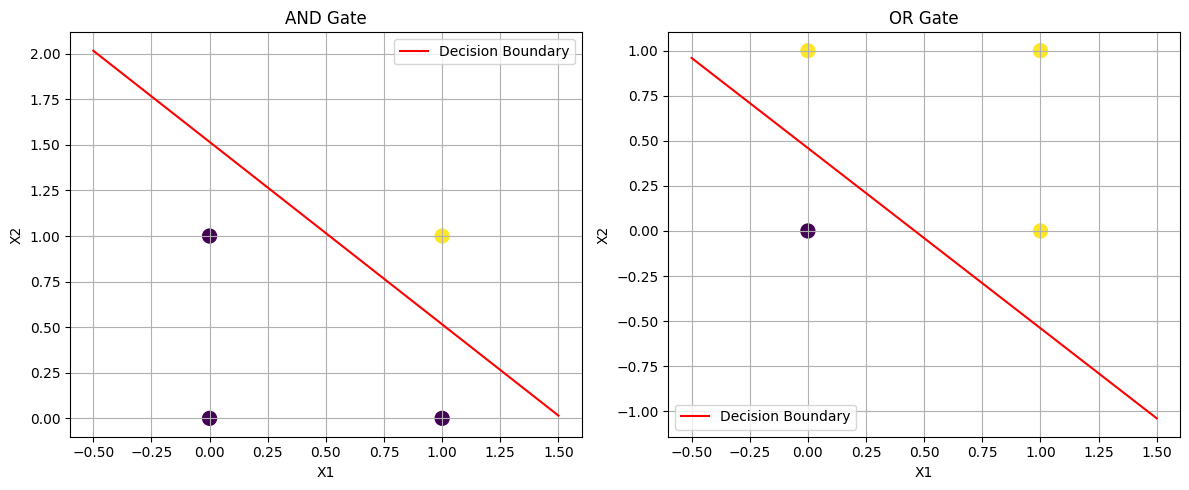

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.linspace(-0.5, 1.5, 100)
y_and_boundary = -(and_perceptron.weights[0] * x + and_perceptron.bias) / and_perceptron.weights[1]
y_or_boundary = -(or_perceptron.weights[0] * x + or_perceptron.bias) / or_perceptron.weights[1]

axes[0].scatter([0, 0, 1, 1], [0, 1, 0, 1], c=[0, 0, 0, 1], cmap='viridis', s=100)
axes[0].plot(x, y_and_boundary, 'r-', label='Decision Boundary')
axes[0].set_title('AND Gate')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].legend()
axes[0].grid(True)

axes[1].scatter([0, 0, 1, 1], [0, 1, 0, 1], c=[0, 1, 1, 1], cmap='viridis', s=100)
axes[1].plot(x, y_or_boundary, 'r-', label='Decision Boundary')
axes[1].set_title('OR Gate')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Interpretation

The neural networks successfully learned to replicate logic gate behavior:

**AND Gate**: Requires both inputs to be high. The learned weights are positive and the bias is negative, creating a decision boundary that only activates when both inputs are 1.

**OR Gate**: Activates when at least one input is high. Similar positive weights but less negative bias allows activation with just one high input.

**NOT Gate**: Single input with negative weight inverts the signal. Positive bias shifts the threshold.

**Training Process**: The perceptron uses gradient descent to adjust weights and bias. The sigmoid activation function provides smooth gradients for learning. Each gate converges to the correct mapping through iterative weight updates based on prediction errors.

**Key Insight**: Simple logic gates can be implemented with single-layer perceptrons, demonstrating the fundamental building blocks of neural computation.